In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [90]:
df = pd.read_csv("../data/processed/heart_processed.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [91]:
X = df.drop("target", axis=1)

y = df["target"]

In [92]:
X = pd.get_dummies(
    X,
    columns=["cp","restecg","slope","thal"],
    drop_first=True,
    dtype=int
)

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [94]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [95]:
log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [96]:
y_pred = log_model.predict(X_test_scaled)

In [97]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.819672131147541


In [98]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83        33
           1       0.79      0.82      0.81        28

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



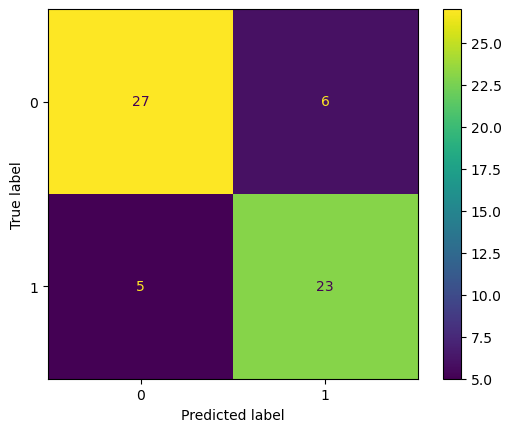

In [99]:
ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test_scaled,
    y_test
)

plt.show()

In [100]:
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.9393939393939394


In [101]:
from sklearn.tree import DecisionTreeClassifier

In [102]:
dt_model = DecisionTreeClassifier(random_state=42)

In [103]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [104]:
dt_pred = dt_model.predict(X_test)

In [105]:
print("Accuracy:", accuracy_score(y_test, dt_pred))

Accuracy: 0.8032786885245902


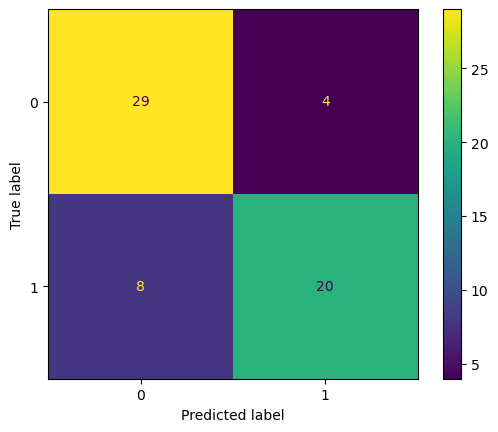

In [106]:
ConfusionMatrixDisplay.from_estimator(
    dt_model,
    X_test,
    y_test
)

plt.show()

In [107]:
dt_prob = dt_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, dt_prob))

ROC-AUC: 0.7965367965367965


In [108]:
from sklearn.ensemble import RandomForestClassifier

In [109]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [110]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [111]:
rf_pred = rf_model.predict(X_test)

In [112]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.8688524590163934


In [113]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



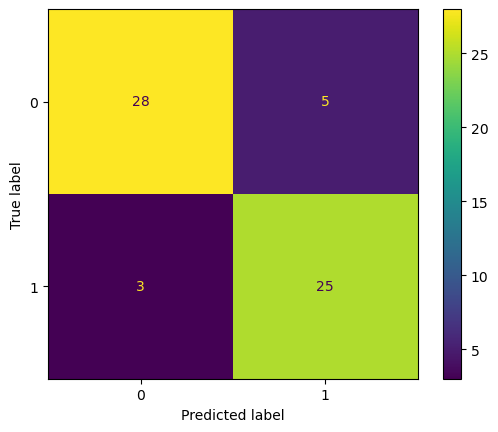

In [114]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.show()

In [115]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

ROC-AUC: 0.9518398268398268


In [116]:
joblib.dump(rf_model, "../artifacts/random_forest.pkl")

['../artifacts/random_forest.pkl']

In [148]:
import joblib

joblib.dump(rf_model, "../artifacts/best_model.pkl")

['../artifacts/best_model.pkl']